## 11) Load Checkpoint And Build Evaluation State
This cell is self-contained: it loads the checkpoint, reconstructs the RNO model, loads Heat data,
and prepares `sol_test_chunks` for rollout testing.


### 11a) Imports and User Configuration


In [1]:
# 11a) Imports and user-editable evaluation inputs
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from neuralop.models import RNO

# Paths
checkpoint_path = "result_rno_state_only_32/rno_state_only_last.pt"
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"

# Optional overrides; if None, values come from checkpoint config when available.
samples_to_load_override = None
train_frac_override = None

# Step 12 params
rollout_h = 5
sample_id = 0
start_chunk = 0

# Step 13 params
eval_steps = [1, 2, 4, 8, 12, 16, 20]
num_windows_per_traj = 10


### 11b) Load Checkpoint (Robust Weights-Only Fallback)


In [2]:
# 11b) Load checkpoint robustly for PyTorch >=2.6
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

try:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    print("Loaded checkpoint with weights_only=True.")
except Exception as weights_only_error:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    print(
        "Loaded checkpoint with weights_only=False fallback:",
        str(weights_only_error).splitlines()[0],
    )


Loaded checkpoint with weights_only=False fallback: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 


### 11c) Parse Checkpoint and Build Model


In [3]:
# 11c) Normalize checkpoint structure, build model, load weights, set seed/device
def parse_checkpoint(ckpt_obj):
    if isinstance(ckpt_obj, torch.nn.Module):
        return ckpt_obj.state_dict(), {}

    if not isinstance(ckpt_obj, dict):
        raise ValueError(f"Unsupported checkpoint object type: {type(ckpt_obj)}")

    if "model_state_dict" in ckpt_obj:
        state_dict = ckpt_obj["model_state_dict"]
        cfg_local = ckpt_obj.get("config", {})
        return state_dict, cfg_local

    return ckpt_obj, {}


state_dict, cfg = parse_checkpoint(ckpt)

if "_metadata" in state_dict and not torch.is_tensor(state_dict["_metadata"]):
    state_dict = {k: v for k, v in state_dict.items() if k != "_metadata"}

# Model hyperparameters
modes1 = cfg.get("modes1", 20)
modes2 = cfg.get("modes2", 20)
width = cfg.get("width", 28)
n_layers = cfg.get("n_layers", 3)
domain_padding = cfg.get("domain_padding", [0.1, 0])
in_channels = cfg.get("in_channels", 1)
out_channels = cfg.get("out_channels", 1)

# Data/chunking hyperparameters
chunk_len = cfg.get("chunk_len", 16)
n_intervals = cfg.get("n_intervals", 5)
sub = cfg.get("sub", 1)
train_frac_ckpt = cfg.get("train_frac", 0.8)

samples_to_load = (
    100 if samples_to_load_override is None else int(samples_to_load_override)
)
train_frac = float(
    train_frac_ckpt if train_frac_override is None else train_frac_override
)

seed = int(ckpt.get("seed", 32)) if isinstance(ckpt, dict) else 32
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)
model.load_state_dict(state_dict, strict=True)
model.eval()

if model.in_channels != 1 or model.out_channels != 1:
    raise ValueError(
        f"This notebook expects state-only RNO with in=out=1. Got in={model.in_channels}, out={model.out_channels}."
    )

print("Checkpoint loaded:", checkpoint_path)
print(f"model.in_channels={model.in_channels}, model.out_channels={model.out_channels}")
print(
    f"seed={seed}, chunk_len={chunk_len}, n_intervals={n_intervals}, sub={sub}, train_frac={train_frac}"
)


Checkpoint loaded: result_rno_state_only_32/rno_state_only_last.pt
model.in_channels=1, model.out_channels=1
seed=32, chunk_len=16, n_intervals=5, sub=1, train_frac=0.8


### 11d) Load Heat Data and Build Test Chunks


In [4]:
# 11d) Load data, preprocess, and build sol_test_chunks
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
).float()  # (ntraj, nt, nx)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

# Spatial subsample
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# Crop time to multiple of chunk_len
ntraj, nt_raw, nx = solutions.shape
nt_usable = nt_raw - (nt_raw % chunk_len)
solutions = solutions[:, :nt_usable, :]

# Same train/test trajectory split as training notebook
n_train_traj = int(train_frac * solutions.shape[0])
n_test_traj = solutions.shape[0] - n_train_traj
sol_test = solutions[n_train_traj:]  # (n_test_traj, nt, nx)


def chunk_time_axis(arr, size):
    return torch.stack(torch.split(arr, size, dim=1), dim=1)


sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test_traj, n_chunks, chunk_len, nx, 1)

print(f"solutions shape: {tuple(solutions.shape)}")
print(f"sol_test_chunks shape: {tuple(sol_test_chunks.shape)}")
print(f"n_test_traj={n_test_traj}, dt={dt}")


solutions shape: (100, 400, 100)
sol_test_chunks shape: (20, 25, 16, 100, 1)
n_test_traj=20, dt=0.001


## 12) Single-Trajectory Native Rollout Test
Runs `model.predict(x0_in, num_steps=rollout_h)` for one test trajectory and compares against ground truth.


x0_in shape: (1, 5, 1, 16, 100)
pred shape: (1, 5, 1, 16, 100)
true chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 1.5224e+00
Rollout relative L2 (h=5): 8.6049e-01


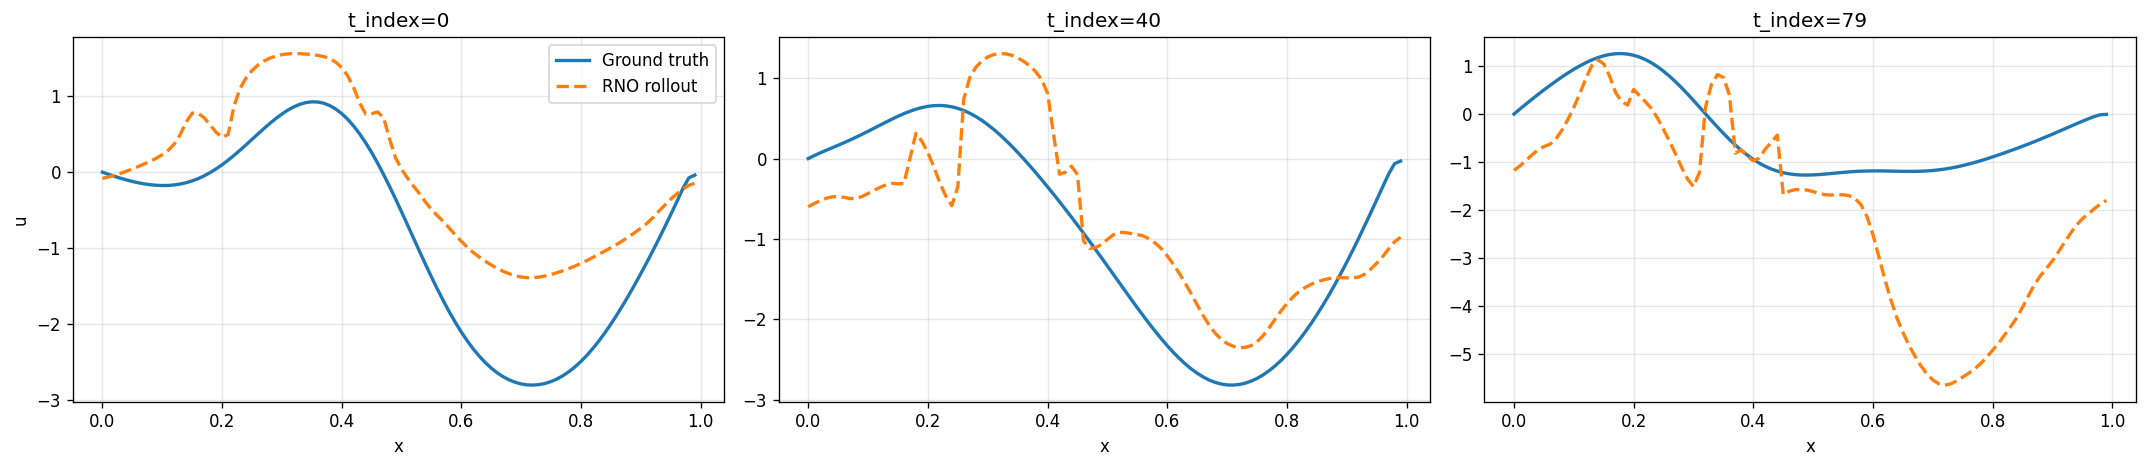

In [5]:
# 12) Single-trajectory rollout and visualization
assert rollout_h >= 1

traj = sol_test_chunks[sample_id]  # (n_chunks, chunk_len, nx, 1)
max_start = traj.shape[0] - n_intervals - rollout_h
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h}. Have n_chunks={traj.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk, max_start)
x0 = traj[start : start + n_intervals].unsqueeze(
    0
)  # (1, n_intervals, chunk_len, nx, 1)
y_true_chunks = traj[
    start + n_intervals : start + n_intervals + rollout_h
]  # (rollout_h, chunk_len, nx, 1)

x0_in = (
    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
)  # (1, n_intervals, 1, chunk_len, nx)

model.eval()
with torch.no_grad():
    pred = model.predict(x0_in, num_steps=rollout_h)  # (1, rollout_h, 1, chunk_len, nx)

pred_chunks = (
    pred[0].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks = y_true_chunks.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"x0_in shape: {tuple(x0_in.shape)}")
print(f"pred shape: {tuple(pred.shape)}")
print(f"true chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h}): {mse_roll:.4e}")
print(f"Rollout relative L2 (h={rollout_h}): {rel_l2_roll:.4e}")

# Quick line comparison at a few rollout times
x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h * chunk_len) // 2), rollout_h * chunk_len - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis,
        pred_flat[tid].numpy(),
        label="RNO rollout",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


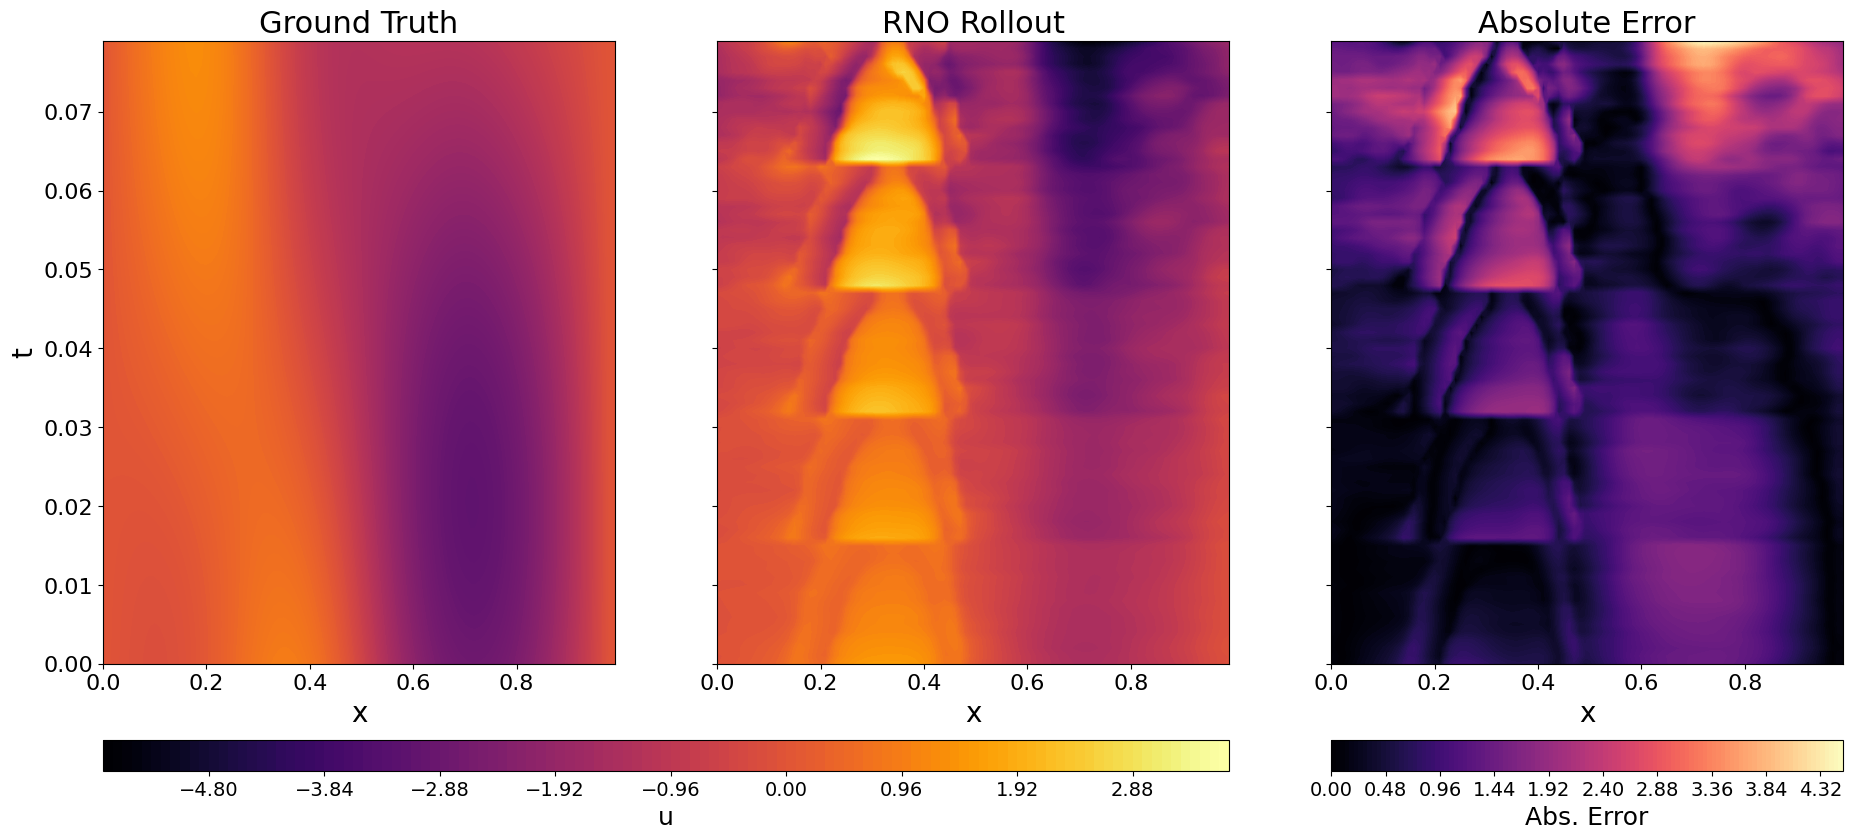

In [6]:
# 12b) Contour-style comparison, matching prior notebook style family
# Uses tensors prepared in the previous section-12 rollout cell: true_flat, pred_flat, x_axis, rollout_h, chunk_len, dt

true_np = true_flat.detach().cpu().numpy()
pred_np = pred_flat.detach().cpu().numpy()
err_np = np.abs(true_np - pred_np)
time_axis = np.linspace(0.0, dt * (rollout_h * chunk_len - 1), rollout_h * chunk_len)

# Save directory for section-12 figures
result_dir = os.path.join("heat", f"result_rno_state_only_eval_{seed}")
os.makedirs(result_dir, exist_ok=True)

# If the line plot path wasn't saved in the previous cell, define a placeholder for printing consistency
if "line_plot_path" not in globals():
    line_plot_path = os.path.join(result_dir, f"rollout_lines_h{rollout_h}.png")

# Contour-style comparison, matching prior notebook style family
vmin = float(min(true_np.min(), pred_np.min()))
vmax = float(max(true_np.max(), pred_np.max()))

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(
    3,
    3,
    height_ratios=[20, 0.3, 1.0],
    width_ratios=[1, 1, 1],
    hspace=0.15,
    wspace=0.2,
    bottom=0.15,
    top=0.88,
    left=0.08,
    right=0.95,
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

im0 = ax0.contourf(
    x_axis, time_axis, true_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax0.set_title("Ground Truth", fontsize=22)
ax0.set_xlabel("x", fontsize=20)
ax0.set_ylabel("t", fontsize=20)
ax0.tick_params(labelsize=16)

im1 = ax1.contourf(
    x_axis, time_axis, pred_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax1.set_title("RNO Rollout", fontsize=22)
ax1.set_xlabel("x", fontsize=20)
ax1.tick_params(labelsize=16, labelleft=False)

im2 = ax2.contourf(x_axis, time_axis, err_np, levels=120, cmap="magma")
ax2.set_title("Absolute Error", fontsize=22)
ax2.set_xlabel("x", fontsize=20)
ax2.tick_params(labelsize=16, labelleft=False)

cbar_ax1 = fig.add_subplot(gs[2, 0:2])
cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("u", fontsize=18)
cbar1.ax.tick_params(labelsize=14)

cbar_ax2 = fig.add_subplot(gs[2, 2])
cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Abs. Error", fontsize=18)
cbar2.ax.tick_params(labelsize=14)

plt.show()

## 13) Multi-Horizon Endpoint Testing (KS-style)
For each horizon `h`, computes endpoint-only metrics over sampled test windows:
- endpoint MSE
- endpoint relative L2


In [7]:
# 13) Multi-horizon endpoint-only evaluation table
rng = np.random.default_rng(seed)
results = {}

model.eval()
with torch.no_grad():
    for h in eval_steps:
        mse_vals = []
        rel_l2_vals = []
        n_eval = 0

        for traj_idx in range(sol_test_chunks.shape[0]):
            traj = sol_test_chunks[traj_idx]  # (n_chunks, chunk_len, nx, 1)
            max_start = traj.shape[0] - n_intervals - h
            if max_start < 0:
                continue

            all_starts = np.arange(max_start + 1)
            if len(all_starts) <= num_windows_per_traj:
                starts = all_starts
            else:
                starts = np.sort(
                    rng.choice(all_starts, size=num_windows_per_traj, replace=False)
                )

            for start in starts:
                # context + endpoint target at horizon h
                x0 = traj[start : start + n_intervals].unsqueeze(
                    0
                )  # (1, n_intervals, chunk_len, nx, 1)
                y_h = (
                    traj[start + n_intervals + (h - 1)].unsqueeze(0).to(device)
                )  # (1, chunk_len, nx, 1)

                x0_in = (
                    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
                )  # (1, n_intervals, 1, chunk_len, nx)
                pred = model.predict(x0_in, num_steps=h)  # (1, h, 1, chunk_len, nx)

                pred_h = pred[:, -1]  # (1, 1, chunk_len, nx)
                pred_h = pred_h.permute(0, 2, 3, 1)  # (1, chunk_len, nx, 1)

                mse = torch.mean((pred_h - y_h) ** 2).item()
                diff_flat = (pred_h - y_h).reshape(1, -1)
                y_flat = y_h.reshape(1, -1)
                rel_l2 = (
                    torch.linalg.norm(diff_flat, dim=1)
                    / (torch.linalg.norm(y_flat, dim=1) + 1e-12)
                ).item()

                mse_vals.append(mse)
                rel_l2_vals.append(rel_l2)
                n_eval += 1

        if n_eval > 0:
            results[h] = {
                "mse_mean": float(np.mean(mse_vals)),
                "rel_l2_mean": float(np.mean(rel_l2_vals)),
                "N": int(n_eval),
            }
        else:
            results[h] = {"mse_mean": float("nan"), "rel_l2_mean": float("nan"), "N": 0}

print("Steps | Endpoint MSE | Endpoint RelL2 | N")
for h in eval_steps:
    r = results[h]
    print(f"{h:>5} | {r['mse_mean']:.4e} | {r['rel_l2_mean']:.4e} | {r['N']}")


Steps | Endpoint MSE | Endpoint RelL2 | N
    1 | 3.5391e-01 | 6.5092e-01 | 200
    2 | 8.1171e-01 | 1.0630e+00 | 200
    4 | 3.2183e+00 | 2.1217e+00 | 200
    8 | 2.8028e+01 | 5.9100e+00 | 200
   12 | 3.5926e+02 | 2.2357e+01 | 180
   16 | 5.1564e+03 | 9.1036e+01 | 100
   20 | 2.0236e+04 | 2.1285e+02 | 20


## 14) Single-Trajectory Rollout Comparison (Three Ablation Models)

Loads the three checkpoints produced by `train_RNO_state_only.ipynb` and compares rollout on the same `(sample_id, start_chunk, rollout_h)`.


In [8]:
# 14a) Configure and load the three ablation checkpoints
ablation_ckpt_dir = os.path.join(os.path.dirname(checkpoint_path), "ablation_three_way")

ablation_checkpoints = {
    "Baseline-only": os.path.join(ablation_ckpt_dir, "baseline_only_state_dict.pt"),
    "Fine-tune-only": os.path.join(ablation_ckpt_dir, "finetune_only_state_dict.pt"),
    "Baseline+Fine-tune": os.path.join(
        ablation_ckpt_dir, "baseline_plus_finetune_state_dict.pt"
    ),
}

for name, ckpt_p in ablation_checkpoints.items():
    if not os.path.exists(ckpt_p):
        raise FileNotFoundError(f"Missing checkpoint for {name}: {ckpt_p}")

print("Ablation checkpoint directory:", ablation_ckpt_dir)
for name, ckpt_p in ablation_checkpoints.items():
    print(f"  {name}: {ckpt_p}")


def load_ckpt_robust(path_local):
    try:
        obj = torch.load(path_local, map_location="cpu", weights_only=True)
        load_mode = "weights_only=True"
    except Exception as err:
        obj = torch.load(path_local, map_location="cpu", weights_only=False)
        load_mode = f"weights_only=False fallback ({str(err).splitlines()[0]})"
    return obj, load_mode


def build_rno_from_checkpoint_obj(ckpt_obj):
    # Prefer explicit model kwargs from training-time checkpoint.
    if not isinstance(ckpt_obj, dict):
        raise ValueError(f"Unsupported checkpoint object type: {type(ckpt_obj)}")

    state_dict_local = ckpt_obj.get("model_state_dict", ckpt_obj)
    if "_metadata" in state_dict_local and not torch.is_tensor(
        state_dict_local["_metadata"]
    ):
        state_dict_local = {
            k: v for k, v in state_dict_local.items() if k != "_metadata"
        }

    mk = ckpt_obj.get("model_kwargs", None)
    cfg_local = ckpt_obj.get("config", {})

    if mk is not None:
        kwargs = {
            "n_modes": tuple(mk.get("n_modes", (modes1, modes2))),
            "hidden_channels": int(mk.get("hidden_channels", width)),
            "in_channels": int(mk.get("in_channels", 1)),
            "out_channels": int(mk.get("out_channels", 1)),
            "n_layers": int(mk.get("n_layers", n_layers)),
            "domain_padding": mk.get("domain_padding", domain_padding),
        }
    else:
        kwargs = {
            "n_modes": (
                cfg_local.get("modes1", modes1),
                cfg_local.get("modes2", modes2),
            ),
            "hidden_channels": int(cfg_local.get("width", width)),
            "in_channels": int(cfg_local.get("in_channels", 1)),
            "out_channels": int(cfg_local.get("out_channels", 1)),
            "n_layers": int(cfg_local.get("n_layers", n_layers)),
            "domain_padding": cfg_local.get("domain_padding", domain_padding),
        }

    model_local = RNO(**kwargs).to(device)
    model_local.load_state_dict(state_dict_local, strict=True)
    model_local.eval()

    if model_local.in_channels != 1 or model_local.out_channels != 1:
        raise ValueError(
            f"Expected state-only model with in=out=1, got in={model_local.in_channels}, out={model_local.out_channels}."
        )

    return model_local


ablation_models = {}
for name, ckpt_p in ablation_checkpoints.items():
    ckpt_obj, mode = load_ckpt_robust(ckpt_p)
    ablation_models[name] = build_rno_from_checkpoint_obj(ckpt_obj)
    print(f"Loaded {name} using {mode}")


Ablation checkpoint directory: result_rno_state_only_32/ablation_three_way
  Baseline-only: result_rno_state_only_32/ablation_three_way/baseline_only_state_dict.pt
  Fine-tune-only: result_rno_state_only_32/ablation_three_way/finetune_only_state_dict.pt
  Baseline+Fine-tune: result_rno_state_only_32/ablation_three_way/baseline_plus_finetune_state_dict.pt
Loaded Baseline-only using weights_only=False fallback (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. )
Loaded Fine-tune-only using weights_only=False fallback (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. )
Loaded Baseline+Fine-tune using weights_only=False fallback (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. )


Shared rollout window -> sample_id=0, start_chunk=0, rollout_h=5
x0_in shape: (1, 5, 1, 16, 100), true chunks shape: (5, 16, 100, 1)
Model | Rollout MSE | Rollout RelL2
----------------------------------------------------
     Baseline-only | 2.3994e+00 | 1.0803e+00
    Fine-tune-only | 1.0622e-01 | 2.2729e-01
Baseline+Fine-tune | 6.4306e-02 | 1.7685e-01


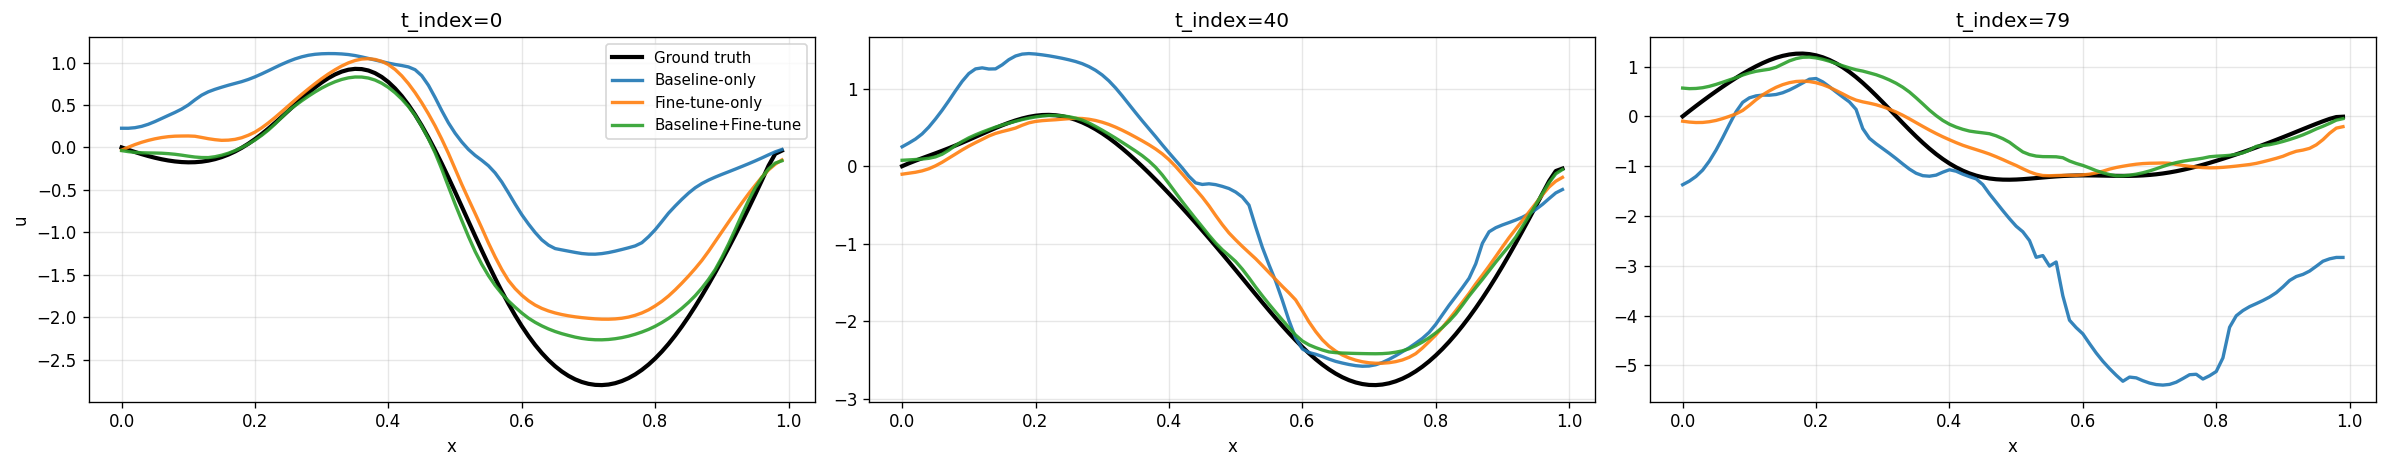

In [14]:
# 14b) Shared single-trajectory rollout window + metrics for all three models
assert rollout_h >= 1

rollout_h = 5

traj = sol_test_chunks[sample_id]  # (n_chunks, chunk_len, nx, 1)
max_start = traj.shape[0] - n_intervals - rollout_h
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h}. Have n_chunks={traj.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk, max_start)
x0 = traj[start : start + n_intervals].unsqueeze(
    0
)  # (1, n_intervals, chunk_len, nx, 1)
y_true_chunks = traj[
    start + n_intervals : start + n_intervals + rollout_h
]  # (rollout_h, chunk_len, nx, 1)

x0_in = (
    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
)  # (1, n_intervals, 1, chunk_len, nx)
true_chunks = y_true_chunks.detach().cpu()
true_flat = true_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

pred_flat_by_model = {}
metrics_by_model = {}

with torch.no_grad():
    for name, model_cmp in ablation_models.items():
        pred = model_cmp.predict(
            x0_in, num_steps=rollout_h
        )  # (1, rollout_h, 1, chunk_len, nx)
        pred_chunks = (
            pred[0].permute(0, 2, 3, 1).detach().cpu()
        )  # (rollout_h, chunk_len, nx, 1)
        pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

        mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
        rel_l2_roll = (
            torch.linalg.norm(pred_flat - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()

        pred_flat_by_model[name] = pred_flat
        metrics_by_model[name] = {"mse": mse_roll, "rel_l2": rel_l2_roll}

print(
    f"Shared rollout window -> sample_id={sample_id}, start_chunk={start}, rollout_h={rollout_h}"
)
print(
    f"x0_in shape: {tuple(x0_in.shape)}, true chunks shape: {tuple(true_chunks.shape)}"
)
print("Model | Rollout MSE | Rollout RelL2")
print("-" * 52)
for name in ablation_checkpoints.keys():
    mm = metrics_by_model[name]
    print(f"{name:>18} | {mm['mse']:.4e} | {mm['rel_l2']:.4e}")

# Line comparison at representative rollout times
x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h * chunk_len) // 2), rollout_h * chunk_len - 1]
colors = {
    "Baseline-only": "#1f77b4",
    "Fine-tune-only": "#ff7f0e",
    "Baseline+Fine-tune": "#2ca02c",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="black",
        linewidth=2.5,
    )
    for name in ablation_checkpoints.keys():
        ax.plot(
            x_axis,
            pred_flat_by_model[name][tid].numpy(),
            label=name,
            color=colors[name],
            linewidth=2,
            alpha=0.9,
        )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("u")
axes[0].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


Shared rollout window -> sample_id=0, start_chunk=0, rollout_h=10
x0_in shape: (1, 5, 1, 16, 100), true chunks shape: (10, 16, 100, 1)
Model | Rollout MSE | Rollout RelL2
----------------------------------------------------
     Baseline-only | 9.2527e+01 | 8.5296e+00
    Fine-tune-only | 3.7814e-01 | 5.4529e-01
Baseline+Fine-tune | 5.2823e-01 | 6.4447e-01


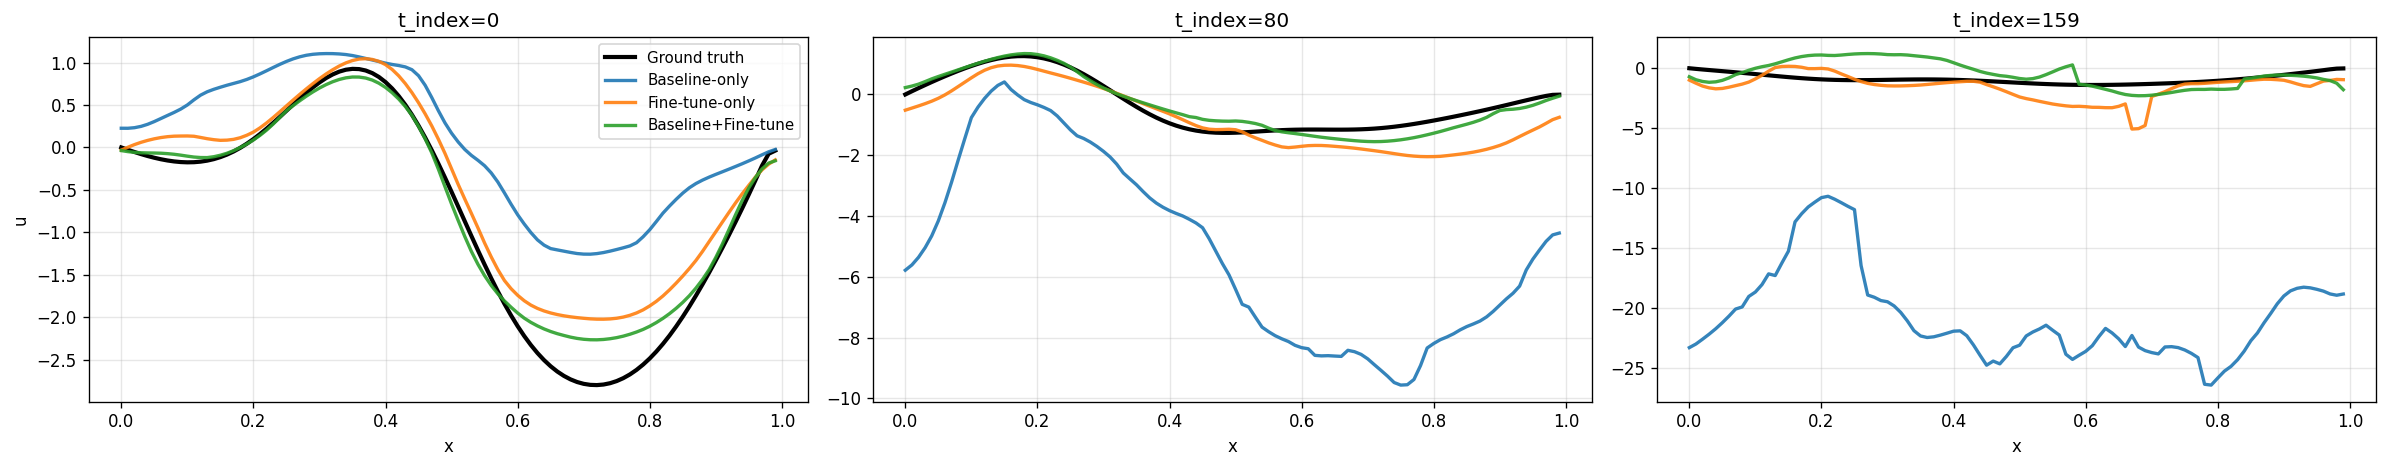

In [17]:
# 14b) Shared single-trajectory rollout window + metrics for all three models
assert rollout_h >= 1

rollout_h = 10

traj = sol_test_chunks[sample_id]  # (n_chunks, chunk_len, nx, 1)
max_start = traj.shape[0] - n_intervals - rollout_h
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h}. Have n_chunks={traj.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk, max_start)
x0 = traj[start : start + n_intervals].unsqueeze(
    0
)  # (1, n_intervals, chunk_len, nx, 1)
y_true_chunks = traj[
    start + n_intervals : start + n_intervals + rollout_h
]  # (rollout_h, chunk_len, nx, 1)

x0_in = (
    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
)  # (1, n_intervals, 1, chunk_len, nx)
true_chunks = y_true_chunks.detach().cpu()
true_flat = true_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

pred_flat_by_model = {}
metrics_by_model = {}

with torch.no_grad():
    for name, model_cmp in ablation_models.items():
        pred = model_cmp.predict(
            x0_in, num_steps=rollout_h
        )  # (1, rollout_h, 1, chunk_len, nx)
        pred_chunks = (
            pred[0].permute(0, 2, 3, 1).detach().cpu()
        )  # (rollout_h, chunk_len, nx, 1)
        pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

        mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
        rel_l2_roll = (
            torch.linalg.norm(pred_flat - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()

        pred_flat_by_model[name] = pred_flat
        metrics_by_model[name] = {"mse": mse_roll, "rel_l2": rel_l2_roll}

print(
    f"Shared rollout window -> sample_id={sample_id}, start_chunk={start}, rollout_h={rollout_h}"
)
print(
    f"x0_in shape: {tuple(x0_in.shape)}, true chunks shape: {tuple(true_chunks.shape)}"
)
print("Model | Rollout MSE | Rollout RelL2")
print("-" * 52)
for name in ablation_checkpoints.keys():
    mm = metrics_by_model[name]
    print(f"{name:>18} | {mm['mse']:.4e} | {mm['rel_l2']:.4e}")

# Line comparison at representative rollout times
x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h * chunk_len) // 2), rollout_h * chunk_len - 1]
colors = {
    "Baseline-only": "#1f77b4",
    "Fine-tune-only": "#ff7f0e",
    "Baseline+Fine-tune": "#2ca02c",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="black",
        linewidth=2.5,
    )
    for name in ablation_checkpoints.keys():
        ax.plot(
            x_axis,
            pred_flat_by_model[name][tid].numpy(),
            label=name,
            color=colors[name],
            linewidth=2,
            alpha=0.9,
        )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("u")
axes[0].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 15) Contour Comparison For All Three Models

Contour-style comparison on the same single-trajectory rollout window used in section 14b.


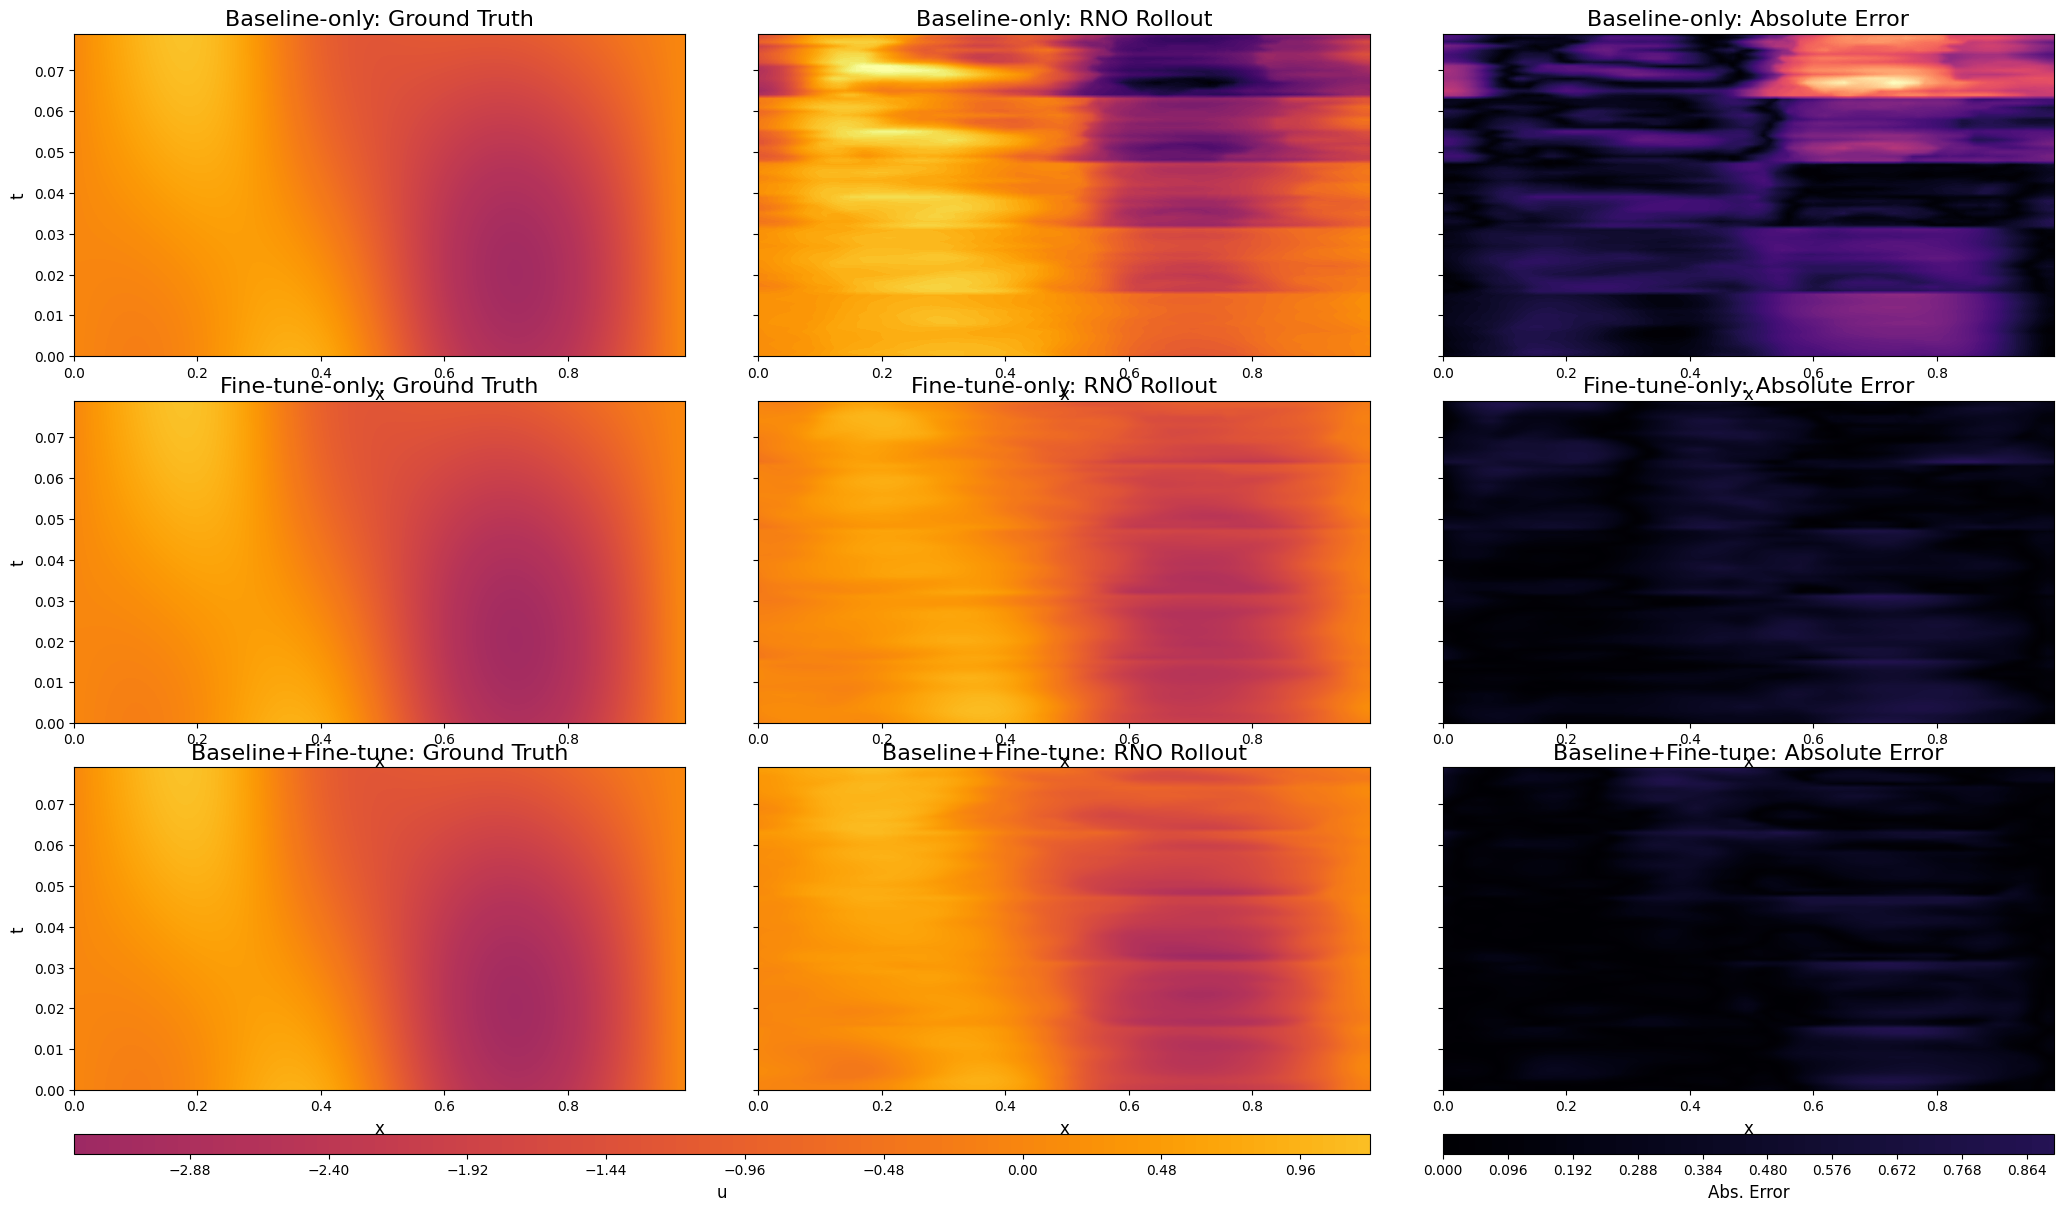

Saved contour comparison plot: heat/result_rno_state_only_eval_32/rollout_contour_compare_three_models_h5.png


In [15]:
# 15) Contour-style comparison for all three models
# Requires section 14b variables: true_flat, pred_flat_by_model, x_axis, rollout_h, chunk_len, dt, seed

model_names = list(ablation_checkpoints.keys())
if not all(name in pred_flat_by_model for name in model_names):
    raise RuntimeError(
        "Missing predictions for one or more models. Run section 14b first."
    )

true_np = true_flat.detach().cpu().numpy()
pred_np_by_model = {
    name: pred_flat_by_model[name].detach().cpu().numpy() for name in model_names
}
err_np_by_model = {
    name: np.abs(pred_np_by_model[name] - true_np) for name in model_names
}

time_axis = np.linspace(0.0, dt * (rollout_h * chunk_len - 1), rollout_h * chunk_len)

# Shared color limits for state fields, and shared limits for absolute error.
all_state_mins = [true_np.min()] + [arr.min() for arr in pred_np_by_model.values()]
all_state_maxs = [true_np.max()] + [arr.max() for arr in pred_np_by_model.values()]
vmin_state = float(min(all_state_mins))
vmax_state = float(max(all_state_maxs))
vmax_err = float(max(arr.max() for arr in err_np_by_model.values()))

# Save directory for section-15 figures
result_dir = os.path.join("heat", f"result_rno_state_only_eval_{seed}")
os.makedirs(result_dir, exist_ok=True)

fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(
    4,
    3,
    height_ratios=[1, 1, 1, 0.06],
    width_ratios=[1, 1, 1],
    hspace=0.18,
    wspace=0.12,
    bottom=0.12,
    top=0.92,
    left=0.06,
    right=0.96,
)

ims_state = []
ims_err = []

for r, name in enumerate(model_names):
    ax0 = fig.add_subplot(gs[r, 0])
    ax1 = fig.add_subplot(gs[r, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[r, 2], sharey=ax0)

    im0 = ax0.contourf(
        x_axis,
        time_axis,
        true_np,
        levels=120,
        cmap="inferno",
        vmin=vmin_state,
        vmax=vmax_state,
    )
    ax0.set_title(f"{name}: Ground Truth", fontsize=16)
    ax0.set_xlabel("x", fontsize=12)
    ax0.set_ylabel("t", fontsize=12)
    ax0.tick_params(labelsize=10)

    im1 = ax1.contourf(
        x_axis,
        time_axis,
        pred_np_by_model[name],
        levels=120,
        cmap="inferno",
        vmin=vmin_state,
        vmax=vmax_state,
    )
    ax1.set_title(f"{name}: RNO Rollout", fontsize=16)
    ax1.set_xlabel("x", fontsize=12)
    ax1.tick_params(labelsize=10, labelleft=False)

    im2 = ax2.contourf(
        x_axis,
        time_axis,
        err_np_by_model[name],
        levels=120,
        cmap="magma",
        vmin=0.0,
        vmax=vmax_err,
    )
    ax2.set_title(f"{name}: Absolute Error", fontsize=16)
    ax2.set_xlabel("x", fontsize=12)
    ax2.tick_params(labelsize=10, labelleft=False)

    ims_state.extend([im0, im1])
    ims_err.append(im2)

cbar_ax_state = fig.add_subplot(gs[3, 0:2])
cbar_state = fig.colorbar(ims_state[-1], cax=cbar_ax_state, orientation="horizontal")
cbar_state.set_label("u", fontsize=12)
cbar_state.ax.tick_params(labelsize=10)

cbar_ax_err = fig.add_subplot(gs[3, 2])
cbar_err = fig.colorbar(ims_err[-1], cax=cbar_ax_err, orientation="horizontal")
cbar_err.set_label("Abs. Error", fontsize=12)
cbar_err.ax.tick_params(labelsize=10)

contour_compare_path = os.path.join(
    result_dir, f"rollout_contour_compare_three_models_h{rollout_h}.png"
)
fig.savefig(contour_compare_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved contour comparison plot: {contour_compare_path}")


## 16) Jump Diagnostics

Line slices before/after a suspicious `t_index` plus numerical jump checks at chunk boundaries.


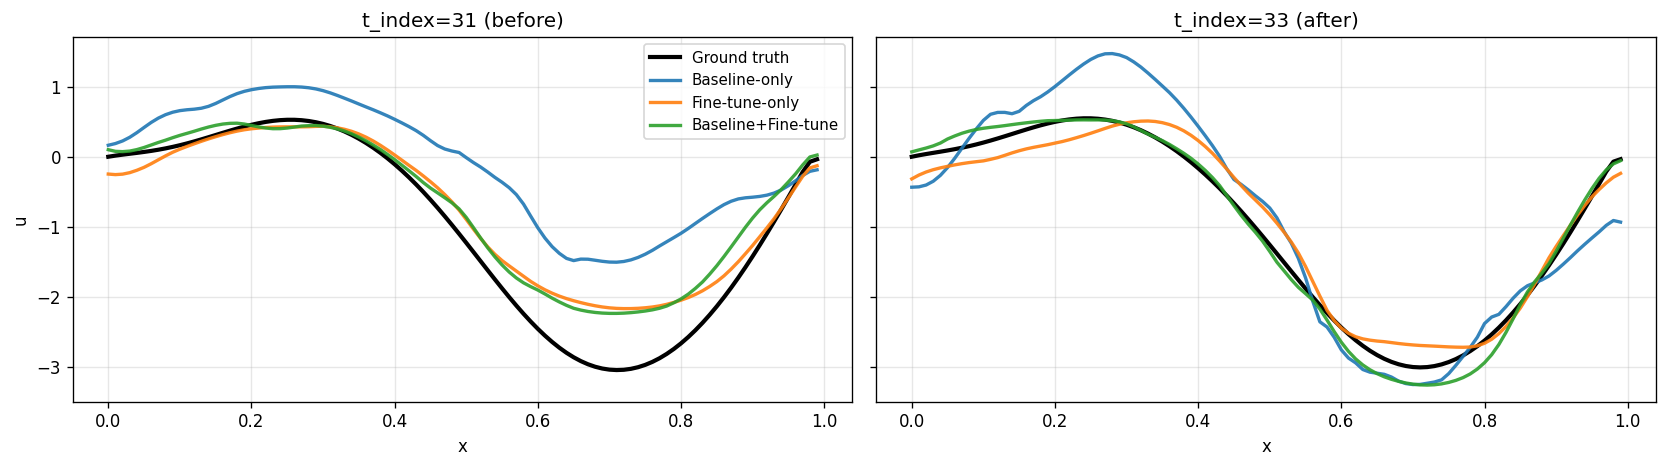

Boundary jump diagnostics (delta = field[t] - field[t-1])
Series | boundary_t_index | mean_abs | max_abs | l2_norm
------------------------------------------------------------------------
      Ground truth |               16 | 1.1469e-02 | 2.9696e-02 | 1.4196e-01
      Ground truth |               32 | 1.4631e-02 | 2.8520e-02 | 1.6462e-01
      Ground truth |               48 | 2.0042e-02 | 3.9537e-02 | 2.3121e-01
      Ground truth |               64 | 1.9949e-02 | 4.6995e-02 | 2.5037e-01
     Baseline-only |               16 | 6.7684e-01 | 1.5065e+00 | 8.1671e+00
     Baseline-only |               32 | 9.1860e-01 | 1.9779e+00 | 1.1272e+01
     Baseline-only |               48 | 1.2228e+00 | 2.4616e+00 | 1.5152e+01
     Baseline-only |               64 | 1.7663e+00 | 3.9388e+00 | 2.0749e+01
    Fine-tune-only |               16 | 1.7051e-01 | 4.4812e-01 | 2.1106e+00
    Fine-tune-only |               32 | 2.7080e-01 | 7.4102e-01 | 3.3833e+00
    Fine-tune-only |               48 | 2.

In [ ]:
# 16) Jump diagnostics: slices around suspicious t_index + boundary jump metrics
# Run section 14b (or 15) first so rollout tensors are available.

if "pred_np_by_model" not in globals():
    if "pred_flat_by_model" not in globals():
        raise RuntimeError("Run section 14b first (missing pred_flat_by_model).")
    pred_np_by_model = {
        name: pred_flat_by_model[name].detach().cpu().numpy()
        for name in pred_flat_by_model
    }

if "true_np" not in globals():
    if "true_flat" not in globals():
        raise RuntimeError("Run section 14b first (missing true_flat).")
    true_np = true_flat.detach().cpu().numpy()

model_names = list(pred_np_by_model.keys())

# Pick suspicious index (can be edited)
suspicious_t_index = 32
n_t = true_np.shape[0]
if not (1 <= suspicious_t_index <= n_t - 2):
    raise ValueError(
        f"suspicious_t_index must be in [1, {n_t - 2}] for before/after slices; got {suspicious_t_index}."
    )

t_before = suspicious_t_index - 1
t_after = suspicious_t_index + 1

# Plot raw line slices just before/after suspicious index
colors = {
    "Ground truth": "black",
    "Baseline-only": "#1f77b4",
    "Fine-tune-only": "#ff7f0e",
    "Baseline+Fine-tune": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120, sharey=True)
for ax, t_idx, ttl in zip(
    axes,
    [t_before, t_after],
    [f"t_index={t_before} (before)", f"t_index={t_after} (after)"],
):
    ax.plot(
        x_axis,
        true_np[t_idx],
        color=colors["Ground truth"],
        linewidth=2.5,
        label="Ground truth",
    )
    for name in model_names:
        ax.plot(
            x_axis,
            pred_np_by_model[name][t_idx],
            linewidth=2,
            alpha=0.9,
            label=name,
            color=colors.get(name, None),
        )
    ax.set_title(ttl)
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("u")
axes[0].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# Numerical boundary-jump checks at chunk edges
boundaries = [16, 32, 48, 64]
valid_boundaries = [b for b in boundaries if 1 <= b < n_t]

series = {"Ground truth": true_np}
for name in model_names:
    series[name] = pred_np_by_model[name]

print(f"Boundary jump diagnostics (delta = field[t] - field[t-1])")
print("Series | boundary_t_index | mean_abs | max_abs | l2_norm")
print("-" * 72)

for sname, arr in series.items():
    for b in valid_boundaries:
        delta = arr[b] - arr[b - 1]
        mean_abs = float(np.mean(np.abs(delta)))
        max_abs = float(np.max(np.abs(delta)))
        l2_norm = float(np.linalg.norm(delta))
        print(f"{sname:>18} | {b:>16} | {mean_abs:.4e} | {max_abs:.4e} | {l2_norm:.4e}")
